In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

# Data Preprocessing

In [63]:
df = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
df

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


In [64]:
df.isna().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

count    630000.000000
mean         54.136706
std           8.256301
min          29.000000
25%          48.000000
50%          54.000000
75%          60.000000
max          77.000000
Name: Age, dtype: float64


<Axes: >

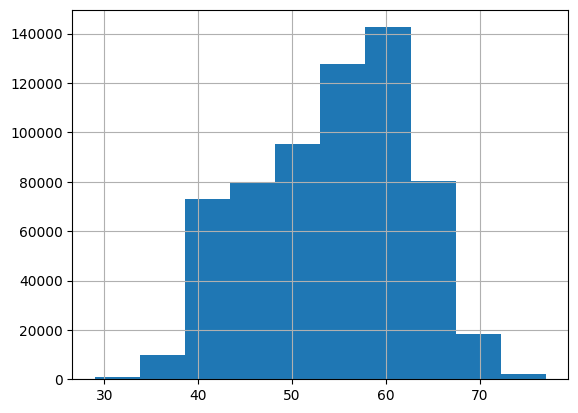

In [65]:
print(df['Age'].describe())
df['Age'].hist()

count    630000.000000
mean          3.312752
std           0.851615
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           4.000000
Name: Chest pain type, dtype: float64


<Axes: >

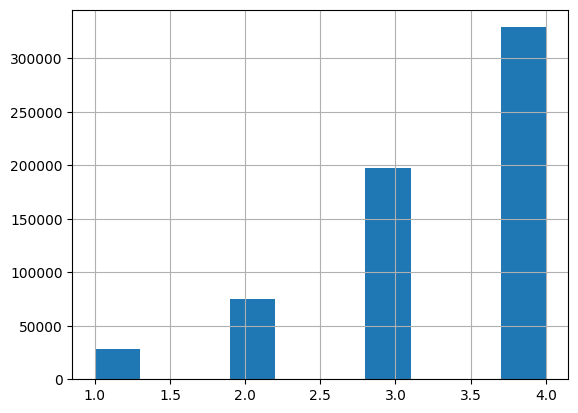

In [66]:
print(df['Chest pain type'].describe())
df['Chest pain type'].hist()

count    630000.000000
mean        130.497433
std          14.975802
min          94.000000
25%         120.000000
50%         130.000000
75%         140.000000
max         200.000000
Name: BP, dtype: float64


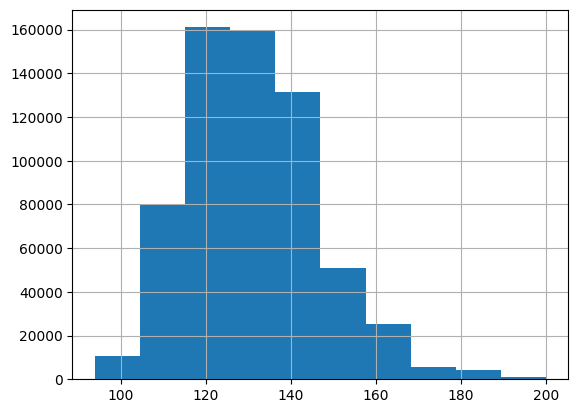

count    630000.000000
mean          4.864937
std           0.112758
min           4.543295
25%           4.787492
50%           4.867534
75%           4.941642
max           5.298317
Name: logBP, dtype: float64


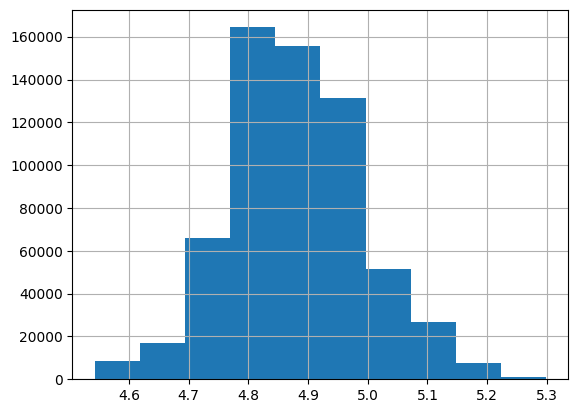

In [67]:
print(df['BP'].describe())
df['BP'].hist()
plt.show()
df['logBP'] = np.log(df['BP'])
print(df['logBP'].describe())
df['logBP'].hist()
plt.show()

In [68]:
def min_max_norm(df,field):
    ma = df[field].max()
    mi = df[field].min()
    df[field] = (df[field]-mi)/(ma-mi)

count    630000.000000
mean          0.426004
std           0.149343
min           0.000000
25%           0.323430
50%           0.429444
75%           0.527597
max           1.000000
Name: logBP, dtype: float64


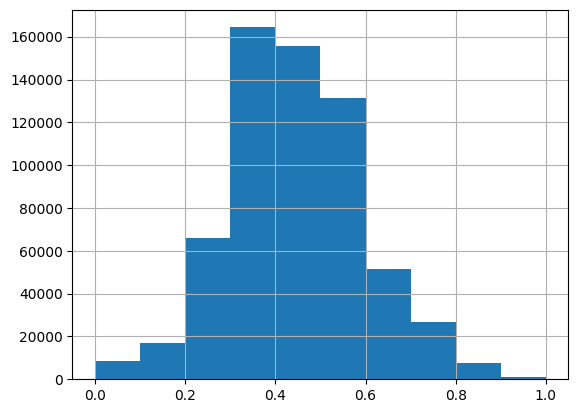

In [69]:
min_max_norm(df,'logBP')
print(df['logBP'].describe())
df['logBP'].hist()
plt.show()

In [70]:
def log_norm(df,field):
    df[('log'+field)] = np.log1p(df[field])
    min_max_norm(df,'log'+field)

count    630000.000000
mean          0.624677
std           0.162469
min           0.000000
25%           0.513466
50%           0.634357
75%           0.742719
max           1.000000
Name: logAge, dtype: float64


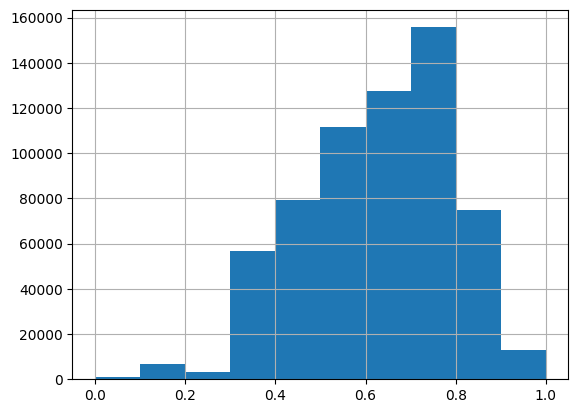

In [71]:
log_norm(df,'Age')
print(df['logAge'].describe())
df['logAge'].hist()
plt.show()

count    630000.000000
mean          0.770917
std           0.283872
min           0.000000
25%           0.666667
50%           1.000000
75%           1.000000
max           1.000000
Name: Chest pain type, dtype: float64


<Axes: >

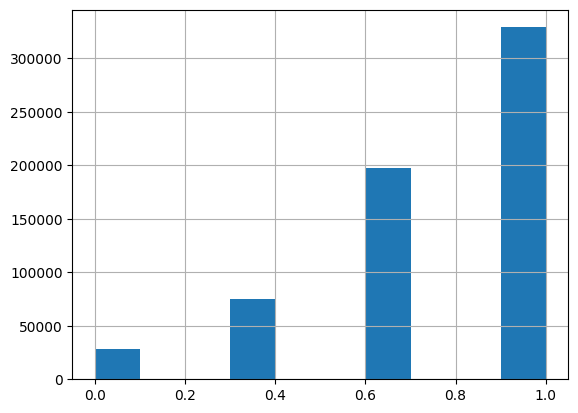

In [72]:
min_max_norm(df,'Chest pain type')
print(df['Chest pain type'].describe())
df['Chest pain type'].hist()

count    630000.000000
mean          0.271716
std           0.076899
min           0.000000
25%           0.221461
50%           0.267123
75%           0.326484
max           1.000000
Name: Cholesterol, dtype: float64


<Axes: >

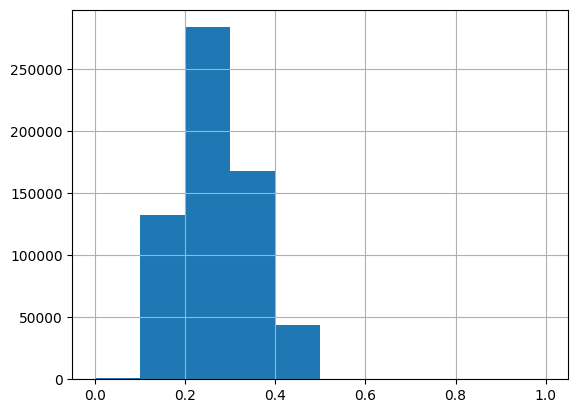

In [73]:
min_max_norm(df,'Cholesterol')
print(df['Cholesterol'].describe())
df['Cholesterol'].hist()

In [74]:
df['EKG results'].value_counts()

EKG results
0    320116
2    308562
1      1322
Name: count, dtype: int64

count    630000.000000
mean          0.724193
std           0.128435
min           0.000000
25%           0.661990
50%           0.758224
75%           0.811669
max           1.000000
Name: logMax HR, dtype: float64


<Axes: >

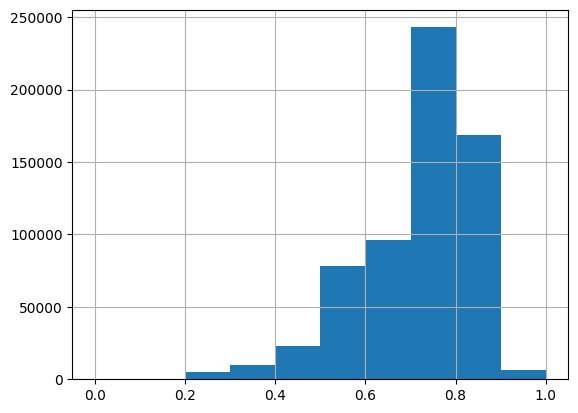

In [75]:
log_norm(df,'Max HR')
print(df['logMax HR'].describe())
df['logMax HR'].hist()

In [76]:
df['ST depression'].describe()

count    630000.000000
mean          0.716028
std           0.948472
min           0.000000
25%           0.000000
50%           0.100000
75%           1.400000
max           6.200000
Name: ST depression, dtype: float64

count    630000.000000
mean          0.208985
std           0.245353
min           0.000000
25%           0.000000
50%           0.048281
75%           0.443482
max           1.000000
Name: logST depression, dtype: float64


<Axes: >

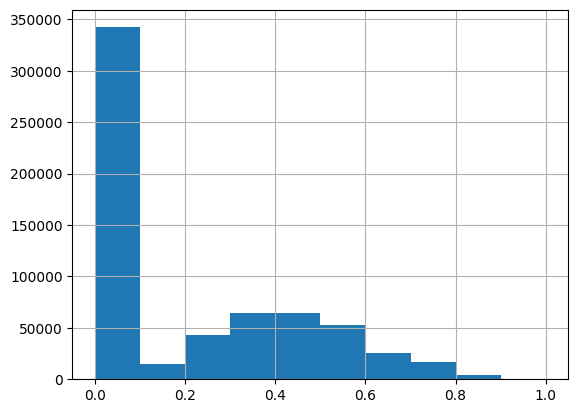

In [77]:
log_norm(df,'ST depression')
print(df['logST depression'].describe())
df['logST depression'].hist()

In [78]:
df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,logBP,logAge,logMax HR,logST depression
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,0.770917,130.497433,0.271716,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873,0.426004,0.624677,0.724193,0.208985
std,181865.479132,8.256301,0.451541,0.283872,14.975802,0.076899,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007,0.149343,0.162469,0.128435,0.245353
min,0.000000,29.000000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,157499.750000,48.000000,0.000000,0.666667,120.000000,0.221461,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.323430,0.513466,0.661990,0.000000
50%,314999.500000,54.000000,1.000000,1.000000,130.000000,0.267123,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,0.429444,0.634357,0.758224,0.048281
75%,472499.250000,60.000000,1.000000,1.000000,140.000000,0.326484,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,0.527597,0.742719,0.811669,0.443482
max,629999.000000,77.000000,1.000000,1.000000,200.000000,1.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000,1.000000,1.000000,1.000000


In [80]:
features = ['logAge','Sex','Chest pain type','logBP','Cholesterol','FBS over 120','EKG results',
            'logMax HR','Exercise angina','logST depression','Slope of ST','Number of vessels fluro','Thallium']
target = 'Heart Disease'

X = df[features]
y = df[target]

In [84]:
X_train,X_test,y_train,y_test = sk.model_selection.train_test_split(X,y,test_size=.25)

In [89]:
rf = sk.ensemble.RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)

RandomForestClassifier()

In [92]:
y_pred = rf.predict(X_test)
accu = sk.metrics.accuracy_score(y_test,y_pred)
print('Accuracy ',accu)

Accuracy  0.8818984126984127


# submission code

In [94]:
test_df = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')

In [99]:
def prep_test(df):
    log_norm(df,'BP')
    log_norm(df,'Age')
    min_max_norm(df,'Chest pain type')
    min_max_norm(df,'Cholesterol')
    log_norm(df,'Max HR')
    log_norm(df,'ST depression')

In [100]:
prep_test(test_df)

y_ans = rf.predict(test_df[features])

In [107]:
ans = pd.DataFrame()
ans['id'] = test_df['id']

ans['Heart Disease'] = (
    pd.Series(y_ans)
      .map({'Presence': 1, 'Absence': 0})
      .astype(int)
)

In [108]:
ans.to_csv('baseline_sub.csv',index=False)

# XGBoost to optimize peformance

In [109]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


In [113]:
N_FOLDS = 5

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=42
)


In [114]:
xgb_params = {
    "n_estimators": 800,
    "learning_rate": 0.05,
    "max_depth": 4,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
}


In [117]:
y = df[target].map({
    'Absence': 0,
    'Presence': 1
}).astype(int)


In [118]:
oof_preds = np.zeros(len(X))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold + 1}/{N_FOLDS}")

    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = XGBClassifier(**xgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"Fold AUC: {fold_auc:.4f}")



Fold 1/5
Fold AUC: 0.9558

Fold 2/5
Fold AUC: 0.9547

Fold 3/5
Fold AUC: 0.9555

Fold 4/5
Fold AUC: 0.9551

Fold 5/5
Fold AUC: 0.9559


In [119]:
cv_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall CV AUC: {cv_auc:.4f}")



Overall CV AUC: 0.9554


In [120]:
X_test = test_df[features]

final_model = XGBClassifier(**xgb_params)
final_model.fit(X, y)

test_probs = final_model.predict_proba(X_test)[:, 1]


In [122]:
ans = pd.DataFrame({
    "id": test_df["id"],
    "Heart Disease": test_probs
})


In [132]:
ans.to_csv("/kaggle/working/xgb_sub.csv", index=False)


In [133]:
pd.read_csv("/kaggle/working/xgb_sub.csv").head()
pd.read_csv("/kaggle/working/xgb_sub.csv").dtypes


id                 int64
Heart Disease    float64
dtype: object